# Recover spatial programs in a simulated atlas

This tutorial introduces the complete SORT workflow on an eight-section
simulated atlas. The input contains 10,368 locations, the 5,000 genes used
for fitting, spatial coordinates and simulated ground truth. We normalize the
counts, fit a common set of programs and compare the recovered spatial
activities with the known programs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import sort

Load the bundled seed-03 atlas. The stored graph connects neighboring
locations within each section and contains no edges between sections.

In [2]:
adata = sc.read_h5ad(Path("../data/simulation/seed_0003.h5ad"))
adata

AnnData object with n_obs × n_vars = 10368 × 5000
    obs: 'sample_id', 'family_name', 'sample_subtype_idx', 'sample_subtype', 'core_region', 'dominant_region', 'dominant_subtype', 'core_mask', 'region_1_mask', 'region_2_mask', 'slice_index', 'spot_id', 'size_factor'
    var: 'Gene', 'BaseGeneMean', 'OutlierFactor', 'GeneMean', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'F_true', 'L_true', 'gep_names', 'hvg', 'sim_params', 'spatial_laplacian', 'tutorial_input'
    obsm: 'spatial'

Apply the normalization used for the simulation experiment. The atlas already
contains the 5,000 selected genes, so no additional feature selection is
needed here.

In [3]:
size_factor = adata.obs["size_factor"].to_numpy(float)
adata.X = adata.X.astype(np.float32).multiply(
    (np.median(size_factor) / size_factor)[:, None]
).tocsr()
adata.X.data = np.log(10.0 * (adata.X.data + 0.1)).astype(np.float32)

Fit 24 components. These few overrides are specific to the simulation; the
remaining settings use the package defaults shared across the manuscript.

In [4]:
result = sort.fit(
    adata,
    n_components=24,
    alpha=1.0,
    lambda_l1_W=0.5,
    stage1_epochs=100,
    device="numpy",
    init_kwargs={"alpha": 10.0, "lambda2": 1e-8},
)
result

SORT: 10,368 locations x 5,000 genes; 24 components


Finished in 77.0 s
Stored .obsm['X_sort'] (10368, 24) and .varm['sort_signatures'] (5000, 24)


SORTResult(W=(10368, 24) spots_x_components, Q=(5000, 24) genes_x_components, background_component=0, fit_time=77.0s)

For evaluation only, match each simulated program to the inferred signal GEP
with the largest signed Pearson correlation. Matching is not used during
fitting.

In [5]:
truth = np.asarray(adata.uns["L_true"], dtype=float)
program_names = np.asarray(adata.uns["gep_names"], dtype=str)
signal_activity = np.asarray(result.W[:, 1:], dtype=float)
correlation = np.corrcoef(truth.T, signal_activity.T)[: truth.shape[1], truth.shape[1] :]
matched_gep = correlation.argmax(axis=1) + 1
recovery = correlation[np.arange(truth.shape[1]), matched_gep - 1]

recovery_table = pd.DataFrame(
    {
        "program": program_names,
        "program_type": [name.split("_", 1)[0] for name in program_names],
        "matched_gep": matched_gep,
        "recovery": recovery,
    }
)
recovery_table

,program,program_type,matched_gep,recovery
0,patient_0,patient,12,0.994983
1,patient_1,patient,13,0.995026
2,patient_2,patient,14,0.992755
3,patient_3,patient,10,0.994773
4,patient_4,patient,17,0.994633
5,patient_5,patient,16,0.993322
6,patient_6,patient,19,0.992329
7,patient_7,patient,18,0.986607
8,subtype_1,subtype,2,0.992559
9,subtype_2,subtype,1,0.989880


The spatial maps show all simulated programs and their matched SORT GEPs in
the same order. Each row uses its own color scale so that strong
patient-specific programs and weaker shared programs remain visible.

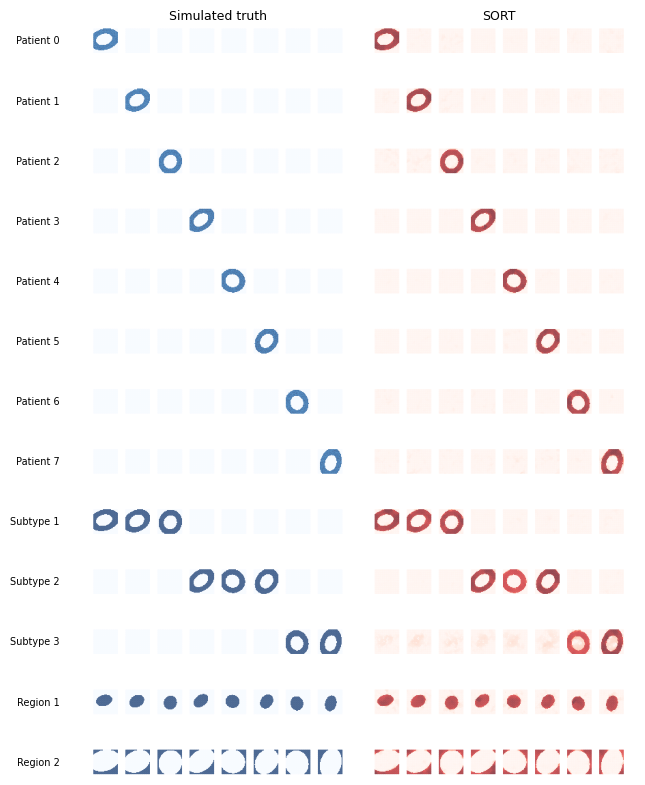

In [6]:
coords = np.asarray(adata.obsm["spatial"])


def rescale(values):
    values = np.asarray(values, dtype=float)
    lo, hi = np.nanmin(values), np.nanmax(values)
    return (values - lo) / (hi - lo) if hi > lo else np.zeros_like(values)


fig, axes = plt.subplots(len(program_names), 2, figsize=(7.2, 8.2))
for row, (name, gep) in enumerate(zip(program_names, matched_gep)):
    for ax, values, cmap in (
        (axes[row, 0], truth[:, row], "Blues"),
        (axes[row, 1], result.W[:, gep], "Reds"),
    ):
        ax.scatter(
            coords[:, 0], coords[:, 1], c=rescale(values), s=0.32,
            cmap=cmap, vmin=0, vmax=1, linewidths=0, rasterized=True,
        )
        ax.set_aspect("equal")
        ax.axis("off")
    axes[row, 0].text(
        -0.08, 0.5, name.replace("_", " ").title(),
        transform=axes[row, 0].transAxes, ha="right", va="center", fontsize=7,
    )
axes[0, 0].set_title("Simulated truth", fontsize=9)
axes[0, 1].set_title("SORT", fontsize=9)
fig.subplots_adjust(left=0.22, right=0.99, top=0.96, bottom=0.01,
                    hspace=0.04, wspace=0.03)
plt.show()

Recovery remains high across patient-specific, subtype-shared and regional
programs. Points represent individual simulated programs and bars show the
mean within each program class.

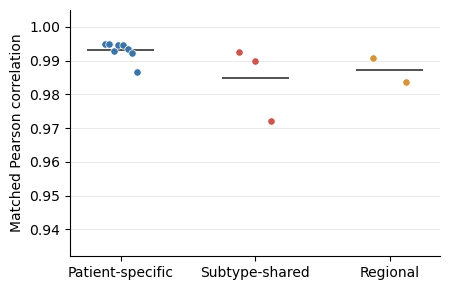

In [7]:
group_order = ["patient", "subtype", "region"]
group_labels = ["Patient-specific", "Subtype-shared", "Regional"]
colors = ["#3D74A6", "#C9574E", "#D4943A"]

fig, ax = plt.subplots(figsize=(4.6, 3.0))
for x, (group, color) in enumerate(zip(group_order, colors)):
    values = recovery_table.loc[recovery_table["program_type"] == group, "recovery"].to_numpy()
    offsets = np.linspace(-0.12, 0.12, len(values))
    ax.scatter(x + offsets, values, s=28, color=color, edgecolor="white",
               linewidth=0.5, zorder=3)
    ax.hlines(values.mean(), x - 0.25, x + 0.25, color="#222222", linewidth=1.1)
ax.set_xticks(range(3), group_labels)
ax.set_ylabel("Matched Pearson correlation")
ax.set_ylim(max(0, recovery.min() - 0.04), 1.005)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#E6E6E6", linewidth=0.6)
fig.tight_layout()
plt.show()